# Chiến lược lướt sóng cổ phiếu theo ngành dẫn dắt, dựa trên tin tức vĩ mô – dòng tiền, kết hợp phân tích kỹ thuật  

### Giới thiệu  
Thị trường chứng khoán Việt Nam mang đặc thù chịu ảnh hưởng mạnh bởi tâm lý nhà đầu tư và diễn biến vĩ mô.  
Trong bối cảnh đó, phương pháp của chúng tôi hướng tới việc **lựa chọn cổ phiếu lướt sóng ngắn hạn** với kỳ vọng **lợi nhuận cao**,  
đồng thời vẫn đảm bảo **an toàn cho nhà đầu tư** nhờ **ứng dụng LLM** trong việc cập nhật và phân tích kịp thời các thông tin vĩ mô.  

---

### Chiến lược giao dịch  
Chiến lược được triển khai qua **3 bước chính**:  

1. **Lựa chọn nhóm ngành mạnh** dự báo cho tuần tới, từ đó sàng lọc ra danh mục cổ phiếu tiềm năng để theo dõi.  
2. **Theo dõi realtime để xác định điểm mua**, nhằm nắm bắt thời điểm tối ưu.  
3. **Chốt lời theo chiến lược**.

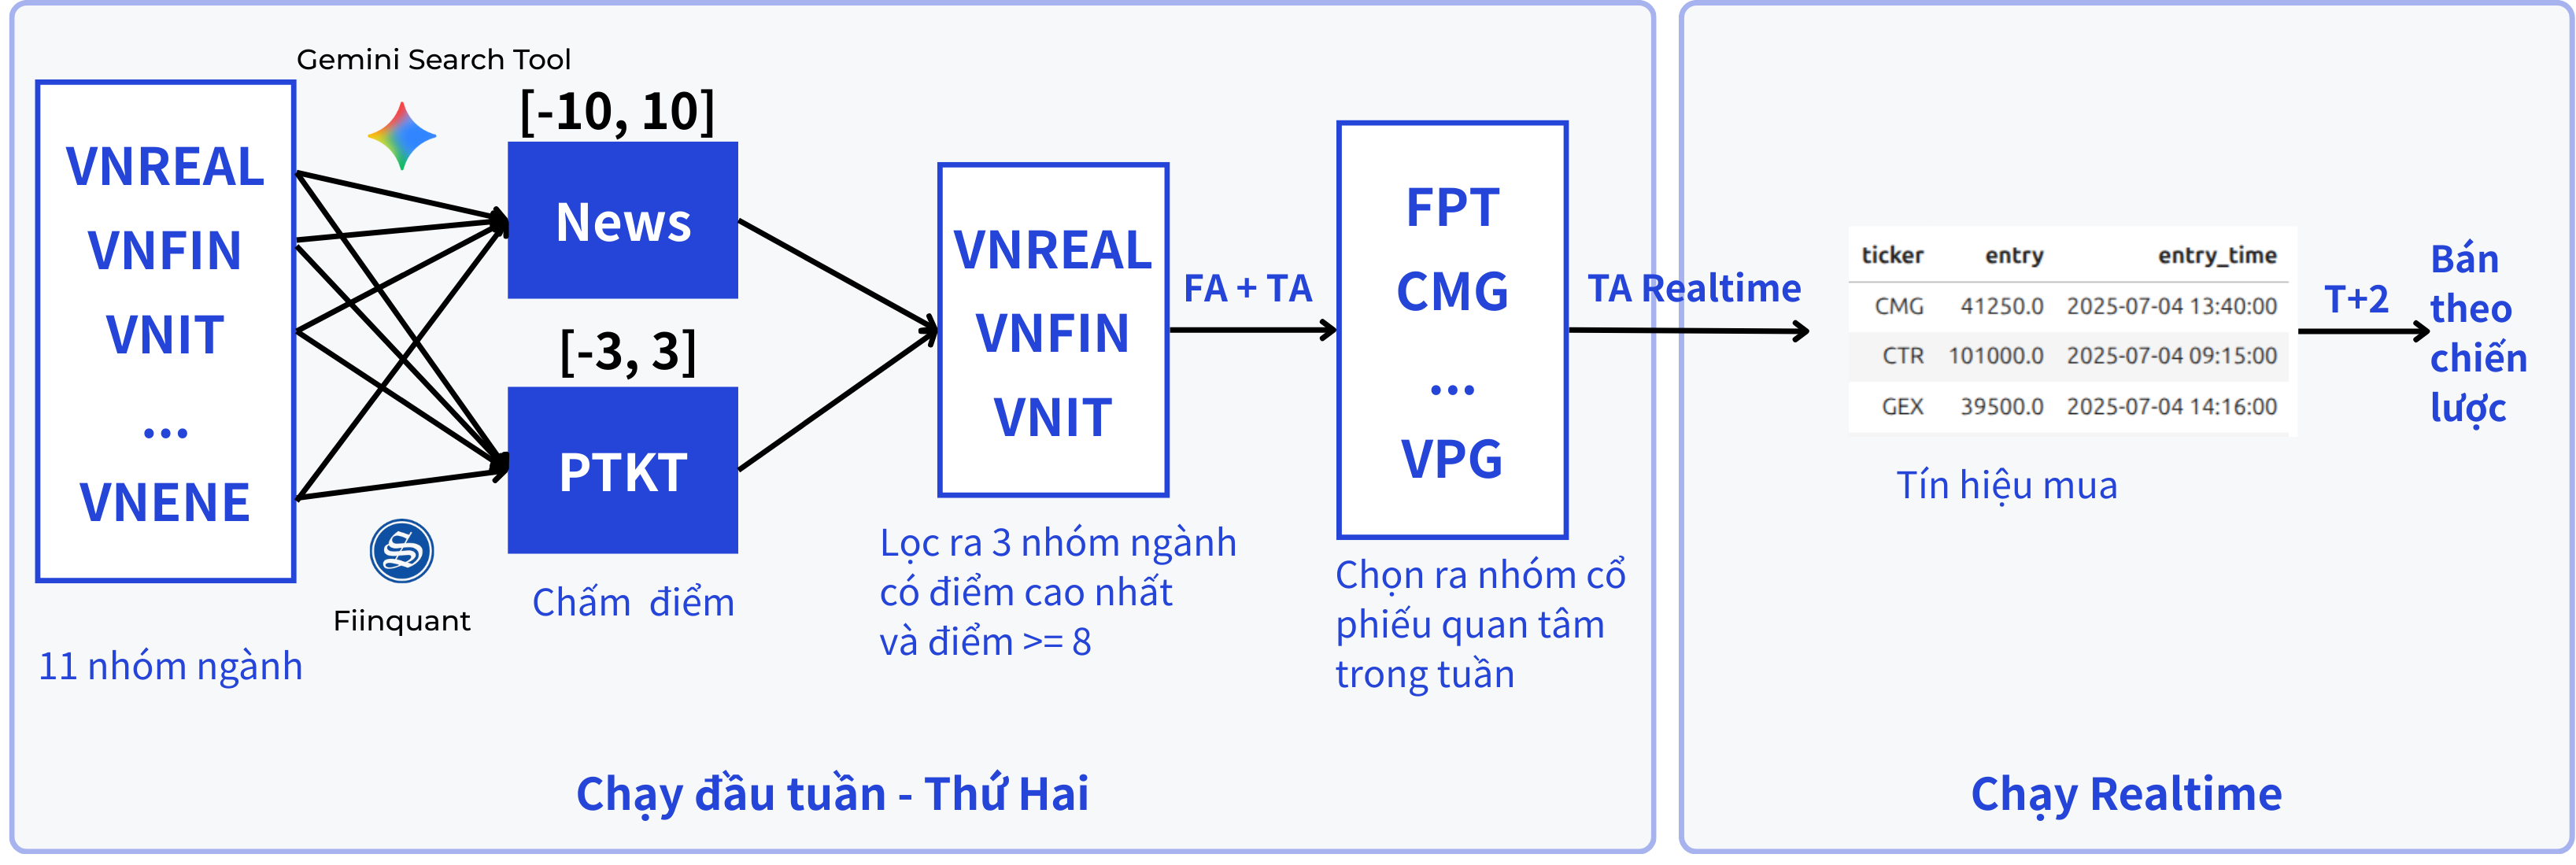

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/res-pnl/pnl_detail.csv
/kaggle/input/res-pnl/pnl_overview.csv
/kaggle/input/signal-t7-25/sectorScores.json
/kaggle/input/signal-t7-25/signal_buy_7_25.csv


# Import thư viện, đăng nhập và kết nối API
- Import các thư viện sử dụng, đặt các giá trị Default, kết nối API Fiinquant và Gemini
- **Code chạy với phiên bản Fiinquant cập nhật trước ngày 4/9. Hàm FA bị lỗi do không tương thích với phiên bản mới**

In [4]:
! pip install -q -U "google-genai>=1.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.8/241.8 kB 6.4 MB/s eta 0:00:00ta 0:00:01


In [ ]:
from FiinQuantX import FiinSession
import pandas as pd
from datetime import datetime, timedelta

# Đăng nhập FiinQuant
username = ""
password = ""

client_fq = FiinSession(username=username, password=password).login()

### Hướng dẫn tạo Gemini API Key

Để sử dụng Gemini API, cần khởi tạo **API key** thông qua Google AI Studio.

#### Bước 1: Truy cập Google AI Studio
- Mở trình duyệt và truy cập: [https://aistudio.google.com/app/apikey](https://aistudio.google.com/app/apikey)  
- Đăng nhập bằng **tài khoản Google** (ví dụ: `tohuy2710@gmail.com`).  

#### Bước 2: Khởi tạo API Key
- Sau khi đăng nhập, chọn **“Create API Key”**.  
- Tiếp tục chọn **“Create API key in new project”** hoặc gắn với một project có sẵn.  
- Hệ thống sẽ cung cấp một **API key** dưới dạng chuỗi ký tự.  
- Vui lòng **sao chép và lưu trữ API key** (lưu ý: khóa chỉ hiển thị một lần duy nhất).  
#### Bước 3: Thay thế API Key vào code dưới đây

In [ ]:
import os
from google.colab import userdata

os.environ['GOOGLE_API_KEY'] = 'API_KEY_HERE'

In [8]:
from google import genai

client_llm = genai.Client() # the API is automatically loaded from the environement variable

MODEL_ID = "gemini-2.5-flash"

In [9]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

In [10]:
DEFAULT_DATE = '2025-07-14'
DEFAULT_DATE_2 = '2025-07-18'

In [39]:
sectorDict = {
        "VNCONS": "TIÊU DÙNG",
        "VNENE": "NĂNG LƯỢNG",
        "VNFIN": "TÀI CHÍNH - NGÂN HÀNG",
        "VNHEAL": "Y TẾ",
        "VNMAT": "NGUYÊN VẬT LIỆU",
        "VNIND": "CÔNG NGHIỆP",
        "VNIT": "CÔNG NGHỆ THÔNG TIN",
        "VNREAL": "BẤT ĐỘNG SẢN",
        "VNUTI": "TIỆN ÍCH",
        "VNCOND": "TIÊU DÙNG KHÔNG THIẾT YẾU"
}

# Functions:

**Filter Sectors**

```getSectorMacroScore(llm=MODEL_ID, sectorCode='VNIT', startDateOfWeek=DEFAULT_DATE)```

	return sc

trả về điểm TA theo LLM phân tích Vĩ mô. Thang điểm 10

```getTAScore(sectorCode='VNIT', startDateOfWeek=DEFAULT_DATE)```

	return score

trả về điểm chấm bằng MFI_14 + RS. Thang điểm 3

```getSectorScore(sectorCode, startDateOfWeek=DEFAULT_DATE)```

    return int(macroScore) + int(taScore)

Nghĩa là tỉ lệ điểm macroScore/TAScore được lấy 10/3

```filterSector(startDateOfWeek)```

**Filter Stocks**

```faStockFilter(sectorCode, target_date="2025-08-28", latest_year=2025, periods=4)```

    return df(ticker  ROE	DebtToEquityRatio	close	avg_vol20	timestamp)
    
```taStockFilter(df_ind, lookback_days=250, target_date="2025-08-28")```

    return df_ind(ticker	signal_buy	entry	entry_time	timestamp) 


In [12]:
from datetime import datetime, timedelta
from IPython.display import HTML, Markdown

def getSectorMacroScore(llm=MODEL_ID, sectorCode='VNIT', startDateOfWeek=DEFAULT_DATE):
    sectorName = sectorDict[sectorCode]

    # parse string date (định dạng YYYY-MM-DD)
    startDate = datetime.strptime(startDateOfWeek, "%Y-%m-%d")
    endDate = startDate + timedelta(days=7)

    # format lại để in cho prompt
    startDateStr = startDate.strftime("%d/%m/%Y")
    endDateStr = endDate.strftime("%d/%m/%Y")

    sundayBefore = startDate - timedelta(days=1)
    sundayBeforeStr = sundayBefore.strftime("%d/%m/%Y")

    prompt_search = f"""
Hãy tìm kiếm và tổng hợp các NHẬN XÉT của BÁO CÁO PHÂN TÍCH TỪ CÁC BÁO, NHÀ ĐẦU TƯ, CHUYÊN GIA
liên quan đến Chứng khoán Việt Nam nhóm ngành {sectorName} trong giai đoạn tuần {startDateStr} - {endDateStr}.
CHỈ TÌM KIẾM các bài viết hoặc nhận định được công bố trong khoảng thời gian TRONG ngày {sundayBeforeStr}.
"""

    print(prompt_search)
    response_search = client_llm.models.generate_content(
        model=llm,
        contents=prompt_search,
        config={"tools": [{"google_search": {}}]},
    )
    
    display(Markdown(f"Response:\n {response_search.text}"))
    #Kiểm định qua search query khi backtest:
    
    # print("Search Query:", response_search.candidates[0].grounding_metadata.web_search_queries)

    # print("Search Pages:")
    # grounding = response_search.candidates[0].grounding_metadata
    # if grounding and grounding.grounding_chunks:
    #     for site in grounding.grounding_chunks:
    #         if hasattr(site, "web") and hasattr(site.web, "uri"):
    #             print(site.web.uri)
    # else:
    #     print("⚠️ Không có link nào được model sử dụng để trả lời.")
    # # Hiển thị khối search UI mặc định
    # display(HTML(response_search.candidates[0].grounding_metadata.search_entry_point.rendered_content))

# -------
    
    prompt_reason = f"""
    Dựa trên nhận định sau, hãy đánh giá tâm lý chung về Chứng khoán Việt Nam trong nhóm ngành {sectorName}.
    Thang điểm: -10 (rất tiêu cực) đến +10 (rất tích cực).
    
    NHẬN ĐỊNH:
    {response_search.text}
    
    ---
    Yêu cầu:
    Trả về kết quả dưới dạng JSON với 2 trường:
    - "summary": tóm tắt ngắn gọn tâm lý chung
    - "score": điểm số (-10 đến 10)
    """

    print(prompt_reason)
    response_reason = client_llm.models.generate_content(
        model=llm,
        contents=prompt_reason,
        # config={"tools": [{"google_search": {}}]},
    )
    
    display(Markdown(f"Response:\n {response_reason.text}"))
    # response_dict = dict(response_reason.text)
    # print(response_dict)
    # test = response_reason
    # score = response_dict['score']
    res_text = response_reason.text
    res_text_str = re.sub(r"^```json\s*|\s*```$", "", res_text.strip(), flags=re.DOTALL)
    js_res = json.loads(res_text_str)
    sc = js_res.get("score", 0)
    return sc

In [13]:
import re

In [14]:
def classify_flow_score(rs: float, mfi: float, mfi_chg: float) -> int:
    
    # Inflow mạnh: giá khỏe, dòng tiền cực cao
    if rs > 0 and mfi >= 80:
        return 3  
    
    # Inflow bền vững: giá khỏe, MFI trung tính-cao, xu hướng MFI tăng
    elif rs > 0 and 40 <= mfi < 80 and mfi_chg >= 0:
        return 2  
    
    # Phân phối: giá khỏe nhưng MFI giảm
    elif rs > 0 and 40 <= mfi < 80 and mfi_chg < 0:
        return 1  
    
    # Outflow mạnh: giá yếu, MFI thấp
    elif rs < 0 and mfi <= 20:
        return -3  
    
    # Outflow tiếp diễn: giá yếu, MFI giảm thêm
    elif rs < 0 and 20 < mfi < 60 and mfi_chg < 0:
        return -2  
    
    # Hồi phục: giá yếu nhưng MFI cải thiện
    elif rs < 0 and (mfi >= 60 or mfi_chg > 0):
        return -1  
    
    # Trung lập
    else:
        return 0  

In [15]:
def getTAScore(sectorCode='VNIT', startDateOfWeek=DEFAULT_DATE):
    start_date = datetime.strptime(startDateOfWeek, "%Y-%m-%d")
    to_date = start_date - timedelta(days=3)  # Thứ 6 tuần trước
    from_date = to_date - relativedelta(months=12) 

    # --- Fetch sector ---
    event = client_fq.Fetch_Trading_Data(
        realtime=False,
        tickers=sectorCode,
        fields=["open", "high", "low", "close", "volume"],
        adjusted=True,
        by="1d",
        from_date=from_date.strftime("%Y-%m-%d"),
        to_date=to_date.strftime("%Y-%m-%d")
    )
    df = event.get_data()
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    df_weekly = df.resample("W-FRI", on="timestamp").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    }).dropna().reset_index()

    # --- Fetch VNI ---
    vni = client_fq.Fetch_Trading_Data(
        realtime=False,
        tickers=["VNINDEX"],
        fields=["close"],
        adjusted=True,
        by="1d",
        from_date=from_date.strftime("%Y-%m-%d"),
        to_date=to_date.strftime("%Y-%m-%d")
    )
    df_vni = vni.get_data()
    df_vni['timestamp'] = pd.to_datetime(df_vni['timestamp'])
    vni_weekly = df_vni.resample("W-FRI", on="timestamp").last().reset_index()

    # --- Merge ---
    df_merged = df_weekly.merge(vni_weekly, on="timestamp", suffixes=("", "_vni"))
    df_merged["RS"] = df_merged["close"] / df_merged["close_vni"]

    # --- MFI ---
    fi = client_fq.FiinIndicator()
    df_merged["MFI_14"] = fi.mfi(df_merged["high"], df_merged["low"],
                                 df_merged["close"], df_merged["volume"], window=14)
    df_merged["MFI_14"] = df_merged["MFI_14"].fillna(0)
    df_merged["MFI_14_pct_change"] = df_merged["MFI_14"].pct_change()

    # --- Lấy tuần gần nhất ---
    last_row = df_merged.iloc[-1]
    score = classify_flow_score(last_row["RS"], last_row["MFI_14"], last_row["MFI_14_pct_change"])

    return score

In [19]:
import json

In [18]:
def getSectorScore(sectorCode, startDateOfWeek=DEFAULT_DATE):
    macroScore = getSectorMacroScore(sectorCode=sectorCode, startDateOfWeek=startDateOfWeek)
    print(macroScore)
    taScore = getTAScore(sectorCode=sectorCode, startDateOfWeek=startDateOfWeek)
    return int(macroScore) + int(taScore)

Lọc cổ phiếu từ Ngành được chọn, Hàm này chạy với phiên bản Fiinquant được cập nhật TRƯỚC NGÀY 4/9. Thực nhiệm trên Môi trường Kaggle lúc 22:45 ngày 4/9 nên Team không kịp chỉnh sửa, rất mong BTC thông cảm ạ :(

In [48]:
import pandas as pd

def faStockFilter(sectorCode, target_date="2025-08-28", latest_year=2025, periods=4):
    """
    Lấy dữ liệu FA + Giá/Volume cho toàn bộ tickers trong 1 ngành
    - Chỉ gọi API 2 lần/ngành: get_ratios + Fetch_Trading_Data
    """
    to_date = datetime.strptime(target_date, "%Y-%m-%d")
    from_date = to_date - timedelta(days=250)
    from_date_str = from_date.strftime("%Y-%m-%d")
    to_date_str = to_date.strftime("%Y-%m-%d")

    # 1. Lấy danh sách tickers trong ngành
    tickers = client_fq.TickerList(ticker=sectorCode)
    if not tickers:
        print(f"Không có mã nào trong ngành {sectorCode}")
        return None

    fa = client_fq.FundamentalAnalysis()
    # Lấy ROE vs Debt/Equity
    fi_dict = fa.get_ratios(
        tickers=tickers,
        TimeFilter="Quarterly",
        LatestYear=latest_year,
        NumberOfPeriod=periods,
        Consolidated=True,
        Fields=["ProfitabilityRatio.ROE", "SolvencyRatio.DebtToEquityRatio"]
    )

    df_fa = pd.DataFrame(fi_dict)
    if df_fa.empty:
        print(f"⚠️ Không có dữ liệu FA cho ngành {sectorCode}")
        return None

    # Tính trung bình 4 quý gần nhất cho từng ticker
    df_fa = df_fa.groupby("ticker")[["ROE","DebtToEquityRatio"]].mean().reset_index()

    #  Lấy dữ liệu giá + volume cho cả ngành
    data = client_fq.Fetch_Trading_Data(
        tickers=tickers,
        fields=["close","volume"],
        adjusted=True,
        realtime=False,
        by="1d",
        from_date=from_date_str,
        to_date=to_date_str
    ).get_data()

    df_px = pd.DataFrame(data)
    if df_px.empty:
        print(f"⚠️ Không có dữ liệu giá cho ngành {sectorCode}")
        return None

    df_px["timestamp"] = pd.to_datetime(df_px["timestamp"])
    # print('display')
    # display(df_px)
    # print('---')
    # # Lọc đến ngày target_date
    # target_date = pd.to_datetime(target_date)
    # df_px = df_px[df_px["timestamp"] <= target_date]

    # Pivot
    df_close = df_px.pivot(index="timestamp", columns="ticker", values="close")
    df_vol   = df_px.pivot(index="timestamp", columns="ticker", values="volume")

    nearest_date = df_close.index[df_close.index <= target_date].max()

    last_close = df_close.loc[nearest_date]
    avg_vol20  = df_vol.rolling(20).mean().loc[nearest_date]

    current_timestamp = nearest_date.strftime('%Y-%m-%d')

    df_px_summary = pd.DataFrame({
        "ticker": last_close.index,
        "close": last_close.values,
        "avg_vol20": avg_vol20.values,
        "timestamp": current_timestamp
    }).reset_index(drop=True)

    # 4. FA + Giá/Vol
    df_final = pd.merge(df_fa, df_px_summary, on="ticker", how="inner")

    for col in ["ROE","DebtToEquityRatio","close","avg_vol20"]:
        df_final[col] = pd.to_numeric(df_final[col], errors="coerce")
    df_final = df_final[
        (df_final["close"] >= 7_000) &
        (df_final["avg_vol20"] >= 50_000) &
        (df_final["ROE"] > 0.1) &
        (df_final["DebtToEquityRatio"] < 1)
    ].reset_index(drop=True)


    return df_final

In [20]:
def taStockFilter(df_ind, lookback_days=250, target_date="2025-08-28"):
    fi = client_fq.FiinIndicator()
    
    tickers = df_ind["ticker"].tolist()
    target_dt = pd.to_datetime(target_date)
    
    # --- 1. Lấy daily history trước ngày target ---
    from_dt = (target_dt - pd.Timedelta(days=lookback_days)).strftime("%Y-%m-%d")
    to_dt   = (target_dt - pd.Timedelta(days=1)).strftime("%Y-%m-%d")

    hist = client_fq.Fetch_Trading_Data(
        tickers=tickers,
        fields=["open","high","low","close","volume"],
        adjusted=True,
        realtime=False,
        by="1d",
        from_date=from_dt,
        to_date=to_dt
    ).get_data()
    df_hist = pd.DataFrame(hist)
    df_hist["timestamp"] = pd.to_datetime(df_hist["timestamp"])

    # --- 2. Lấy dữ liệu intraday từng phút trong ngày target ---
    intra = client_fq.Fetch_Trading_Data(
        tickers=tickers,
        fields=["open","high","low","close","volume"],
        adjusted=True,
        realtime=False,
        by="1m",
        from_date=target_dt.strftime("%Y-%m-%d 09:00"),
        to_date=target_dt.strftime("%Y-%m-%d 15:00")  # cả ngày, sẽ loop từng phút
    ).get_data()
    df_intra = pd.DataFrame(intra)
    df_intra["timestamp"] = pd.to_datetime(df_intra["timestamp"])

    signals, entries, entry_times = [], [], []

    # --- 3. Xử lý từng ticker ---
    for t in tickers:
        try:
            # Dữ liệu lịch sử của ticker
            df_t_hist = df_hist[df_hist["ticker"] == t].copy()

            # Dữ liệu intraday của ticker
            df_t_intra = df_intra[df_intra["ticker"] == t].copy().sort_values("timestamp")

            signal, entry_price, entry_time = "NO TRADE", None, None

            # Loop từng phút trong ngày target
            for current_time in df_t_intra["timestamp"].unique():
                df_until_now = df_t_intra[df_t_intra["timestamp"] <= current_time]

                # Aggregate thành nến tạm tại thời điểm hiện tại
                o = df_until_now["open"].iloc[0]
                h = df_until_now["high"].max()
                l = df_until_now["low"].min()
                c = df_until_now["close"].iloc[-1]
                v = df_until_now["volume"].sum()

                # Ghép vào dữ liệu lịch sử để tính indicator
                df_tmp = pd.concat([
                    df_t_hist[["timestamp","open","high","low","close","volume"]],
                    pd.DataFrame([{"timestamp": target_dt, "open": o, "high": h, "low": l, "close": c, "volume": v}])
                ], ignore_index=True).set_index("timestamp").sort_index()

                close = df_tmp["close"]
                high  = df_tmp["high"]
                low   = df_tmp["low"]
                vol   = df_tmp["volume"]

                # Weekly ADX
                close_w = close.resample("W-FRI").last().dropna()
                high_w  = high.resample("W-FRI").max().reindex(close_w.index)
                low_w   = low.resample("W-FRI").min().reindex(close_w.index)
                adx_week = fi.adx(high_w, low_w, close_w, window=14).iloc[-1]

                # Daily indicators tại phút này
                adx_day   = fi.adx(high, low, close, window=14).iloc[-1]
                ema20     = fi.ema(close, window=20).iloc[-1]
                ema50     = fi.ema(close, window=50).iloc[-1]
                macd_line = fi.macd(close, window_fast=12, window_slow=26).iloc[-1]
                macd_sig  = fi.macd_signal(close, window_fast=12, window_slow=26, window_sign=9).iloc[-1]
                vol_ma20  = vol.rolling(20).mean().iloc[-1]

                last_close = c
                last_vol   = v

                # --- Logic tín hiệu ---
                if adx_week > 25:
                    if adx_day > 25:
                        if (last_close > ema20) and (last_close > ema50) and (macd_line > macd_sig):
                            if last_vol > vol_ma20:
                                signal = "BUY breakout"
                                entry_price = last_close
                                entry_time = current_time
                                break  # dừng ngay khi có tín hiệu
                    elif adx_day < 20:
                        if (last_close > ema20) and (last_close > ema50) and (macd_line > macd_sig):
                            signal = "BUY dip"
                            entry_price = last_close
                            entry_time = current_time
                            break  # dừng ngay khi có tín hiệu

            signals.append(signal)
            entries.append(entry_price)
            entry_times.append(entry_time)

        except Exception as e:
            print(f"Lỗi xử lý {t}: {e}")
            signals.append("NO DATA")
            entries.append(None)
            entry_times.append(None)

    df_ind["signal_buy"] = signals
    df_ind["entry"] = entries
    df_ind["entry_time"] = entry_times
    df_ind["timestamp"] = target_dt
    return df_ind

In [21]:
def getSignalBuy(df, targetDate):
    df = taStockFilter(df, target_date=targetDate)
    df = df[df['signal_buy'] != 'NO TRADE']
    return df[['ticker', 'timestamp', 'signal_buy', 'entry', 'entry_time']]

# Ví dụ Backtest Tháng 8/2025

Giai đoạn backtest:
- mondays: các ngày Thứ Hai bắt đầu tuần giao dịch
- fridays: thứ 6 tương ứng

In [34]:
mondays = ['2025-08-11']
fridays = ['2025-08-15']

tạo sectorScores mặc định là 0 điểm

In [35]:
sectorScores = {
    day: {sector: 0 for sector in sectorDict.keys()}
    for day in mondays
}

In [36]:
sectorScores

{'2025-08-11': {'VNCONS': 0,
  'VNENE': 0,
  'VNFIN': 0,
  'VNHEAL': 0,
  'VNMAT': 0,
  'VNIND': 0,
  'VNIT': 0,
  'VNREAL': 0,
  'VNUTI': 0,
  'VNCOND': 0}}

In [42]:
# sectorScores[mondays[0]]['VNCONS'] = getSectorScore('VNCONS', mondays[0])
# sectorScores[mondays[0]]['VNENE']  = getSectorScore('VNENE', mondays[0])
# sectorScores[mondays[0]]['VNFIN']  = getSectorScore('VNFIN', mondays[0])
# sectorScores[mondays[0]]['VNHEAL'] = getSectorScore('VNHEAL', mondays[0])
# sectorScores[mondays[0]]['VNMAT']  = getSectorScore('VNMAT', mondays[0])
# sectorScores[mondays[0]]['VNIND']  = getSectorScore('VNIND', mondays[0])
# sectorScores[mondays[0]]['VNIT']   = getSectorScore('VNIT', mondays[0])
# sectorScores[mondays[0]]['VNREAL'] = getSectorScore('VNREAL', mondays[0])
# sectorScores[mondays[0]]['VNUTI']  = getSectorScore('VNUTI', mondays[0])
sectorScores[mondays[0]]['VNCOND'] = getSectorScore('VNCOND', mondays[0])


Hãy tìm kiếm và tổng hợp các NHẬN XÉT của BÁO CÁO PHÂN TÍCH TỪ CÁC BÁO, NHÀ ĐẦU TƯ, CHUYÊN GIA
liên quan đến Chứng khoán Việt Nam nhóm ngành TIÊU DÙNG KHÔNG THIẾT YẾU trong giai đoạn tuần 11/08/2025 - 18/08/2025.
CHỈ TÌM KIẾM các bài viết hoặc nhận định được công bố trong khoảng thời gian TRONG ngày 10/08/2025.



Response:
 Dựa trên các báo cáo và nhận định được công bố vào hoặc xung quanh ngày 10/08/2025, có một số đánh giá liên quan đến thị trường chứng khoán Việt Nam nói chung và ngành tiêu dùng, bao gồm cả nhóm ngành tiêu dùng không thiết yếu, mặc dù các nhận định chuyên sâu chỉ dành riêng cho nhóm ngành này trong tuần 11/08/2025 - 18/08/2025 là không nhiều.

**Tổng hợp nhận định từ các báo, nhà đầu tư, chuyên gia (công bố vào ngày 10/08/2025 hoặc rất gần):**

*   **Tổng quan thị trường chứng khoán tuần mới (từ 11/08/2025):** Theo FiinPro, vào ngày 10/08/2025, "Tin chính cuối tuần" đưa ra nhận định rằng SSI Research kỳ vọng VN-Index hướng tới vùng 1.800 điểm. Các chuyên gia cũng có cái nhìn về "chu kỳ tăng mới cho nhóm cổ phiếu đầu tư công" và nhận định rằng 2025 vẫn đang là giai đoạn "chân sóng" nếu nhìn trong xu hướng trung và dài hạn. Mặc dù thị trường có thể có tín hiệu yếu đi trong các phiên cuối tuần trước đó với các mẫu hình nến đảo chiều, cho thấy khả năng điều chỉnh ngắn hạn trong tuần tới, nhưng nhìn chung xu hướng tăng vẫn được kỳ vọng.
*   **Nhận định về cổ phiếu cụ thể trong nhóm ngành tiêu dùng không thiết yếu:** Công ty Chứng khoán Bảo Việt (BVSC) vào ngày 08/08/2025 đã đưa ra khuyến nghị "khả quan" đối với cổ phiếu MCH (CTCP Hàng tiêu dùng Masan). BVSC điều chỉnh giảm dự phóng doanh thu, EBITDA và lợi nhuận sau thuế của MCH cho năm 2025 do tác động của chính sách thuế hộ kinh doanh và việc một số sản phẩm mới lùi lịch quảng bá sang nửa cuối năm 2025. Tuy nhiên, BVSC vẫn duy trì khuyến nghị khả quan với giá mục tiêu 146.900 đồng/cổ phiếu, nhấn mạnh MCH là doanh nghiệp FMCG đáng chú ý với đội ngũ lãnh đạo tâm huyết, chiến lược bài bản và các nhãn hiệu mạnh có khả năng cạnh tranh bền bỉ. Việc MCH có kế hoạch niêm yết trên HSX trong giai đoạn 2025-2026 cũng có thể gia tăng khả năng tiếp cận nhà đầu tư.
*   **Xu hướng dài hạn của ngành tiêu dùng không thiết yếu:** Các báo cáo phân tích trước đó trong năm 2025 và cuối năm 2024 cũng đã đưa ra cái nhìn về triển vọng của ngành tiêu dùng không thiết yếu trong năm 2025:
    *   Một báo cáo vào ngày 04/12/2024 nhận định rằng sự phục hồi của ngành hàng tiêu dùng nhanh (FMCG) sẽ được dẫn dắt bởi các ngành hàng không thiết yếu, với quy mô thị trường bán lẻ Việt Nam dự kiến tăng mạnh từ 276,37 tỷ USD năm 2024 lên 488,08 tỷ USD vào năm 2029. Các sản phẩm không thiết yếu như bia và thuốc lá được kỳ vọng dẫn đầu tăng trưởng.
    *   SSI Research vào ngày 25/06/2025 cũng cho thấy ngành tiêu dùng Việt Nam đang chuyển đổi mạnh mẽ, với sự tăng trưởng của các kênh bán lẻ hiện đại và thương mại điện tử. Các nhóm hàng như bia, ô tô và dược phẩm dẫn đầu xu hướng tăng trưởng, đồng thời doanh thu từ điện thoại di động và laptop cũng tăng đáng kể.
    *   Tuy nhiên, một báo cáo từ IVS vào ngày 09/01/2025 lại ưu tiên cổ phiếu ngành hàng tiêu dùng thiết yếu hơn so với không thiết yếu trong năm 2025, do người tiêu dùng Việt Nam vẫn có xu hướng thận trọng trước áp lực kinh tế như lạm phát và lãi suất cao.

Nhìn chung, vào khoảng thời gian yêu cầu, các nhận định chủ yếu tập trung vào triển vọng chung của thị trường chứng khoán Việt Nam với kỳ vọng tăng trưởng dài hạn và khả năng điều chỉnh ngắn hạn. Đối với nhóm ngành tiêu dùng không thiết yếu, các đánh giá trước đó cho thấy tiềm năng tăng trưởng trong dài hạn được dẫn dắt bởi sự phục hồi kinh tế và sự mở rộng của tầng lớp trung lưu, dù vẫn có những lo ngại về sự thận trọng của người tiêu dùng và áp lực kinh tế ngắn hạn. Cổ phiếu Masan Consumer (MCH) nhận được khuyến nghị tích cực vào gần thời điểm đó.


    Dựa trên nhận định sau, hãy đánh giá tâm lý chung về Chứng khoán Việt Nam trong nhóm ngành TIÊU DÙNG KHÔNG THIẾT YẾU.
    Thang điểm: -10 (rất tiêu cực) đến +10 (rất tích cực).
    
    NHẬN ĐỊNH:
    Dựa trên các báo cáo và nhận định được công bố vào hoặc xung quanh ngày 10/08/2025, có một số đánh giá liên quan đến thị trường chứng khoán Việt Nam nói chung và ngành tiêu dùng, bao gồm cả nhóm ngành tiêu dùng không thiết yếu, mặc dù các nhận định chuyên sâu chỉ dành riêng cho nhóm ngành này trong tuần 11/08/2025 - 18/08/2025 là không nhiều.

**Tổng hợp nhận định từ các báo, nhà đầu tư, chuyên gia (công bố vào ngày 10/08/2025 hoặc rất gần):**

*   **Tổng quan thị trường chứng khoán tuần mới (từ 11/08/2025):** Theo FiinPro, vào ngày 10/08/2025, "Tin chính cuối tuần" đưa ra nhận định rằng SSI Research kỳ vọng VN-Index hướng tới vùng 1.800 điểm. Các chuyên gia cũng có cái nhìn về "chu kỳ tăng mới cho nhóm cổ phiếu đầu tư công" và nhận định rằng 2025 vẫn đang là giai đoạn "chân sóng" nế

Response:
 ```json
{
  "summary": "Tâm lý chung cho nhóm ngành Tiêu dùng không thiết yếu là tích cực về dài hạn, với kỳ vọng tăng trưởng mạnh của thị trường bán lẻ và các khuyến nghị khả quan cho cổ phiếu chủ chốt như MCH. Tuy nhiên, vẫn tồn tại sự thận trọng trong ngắn hạn do khả năng điều chỉnh của thị trường chung, cùng với lo ngại về tâm lý tiêu dùng thắt chặt và áp lực kinh tế trong năm 2025 khiến dự báo lợi nhuận của MCH cũng bị điều chỉnh giảm, và một số chuyên gia ưu tiên nhóm hàng thiết yếu hơn.",
  "score": 3
}
```

3
Fetching data, it may take a while. Please wait...
Fetching data, it may take a while. Please wait...


In [44]:
sectorScores[mondays[0]]

{'VNCONS': 11,
 'VNENE': 11,
 'VNFIN': 10,
 'VNHEAL': 10,
 'VNMAT': 8,
 'VNIND': 7,
 'VNIT': 4,
 'VNREAL': 8,
 'VNUTI': 10,
 'VNCOND': 6}

In [ ]:
# sectorScores[mondays[1]]['VNCONS'] = getSectorScore('VNCONS', mondays[1])
# sectorScores[mondays[1]]['VNENE']  = getSectorScore('VNENE', mondays[1])
# sectorScores[mondays[1]]['VNFIN']  = getSectorScore('VNFIN', mondays[1])
# sectorScores[mondays[1]]['VNHEAL'] = getSectorScore('VNHEAL', mondays[1])
# sectorScores[mondays[1]]['VNMAT']  = getSectorScore('VNMAT', mondays[1])
# sectorScores[mondays[1]]['VNIND']  = getSectorScore('VNIND', mondays[1])
# sectorScores[mondays[1]]['VNIT']   = getSectorScore('VNIT', mondays[1])
# sectorScores[mondays[1]]['VNREAL'] = getSectorScore('VNREAL', mondays[1])
# sectorScores[mondays[1]]['VNUTI']  = getSectorScore('VNUTI', mondays[1])
# sectorScores[mondays[1]]['VNCOND'] = getSectorScore('VNCOND', mondays[1])

In [ ]:
# sectorScores[mondays[2]]['VNCONS'] = getSectorScore('VNCONS', mondays[2])
# sectorScores[mondays[2]]['VNENE']  = getSectorScore('VNENE', mondays[2])
# sectorScores[mondays[2]]['VNFIN']  = getSectorScore('VNFIN', mondays[2])
# sectorScores[mondays[2]]['VNHEAL'] = getSectorScore('VNHEAL', mondays[2])
# sectorScores[mondays[2]]['VNMAT']  = getSectorScore('VNMAT', mondays[2])
# sectorScores[mondays[2]]['VNIND']  = getSectorScore('VNIND', mondays[2])
# sectorScores[mondays[2]]['VNIT']   = getSectorScore('VNIT', mondays[2])
# sectorScores[mondays[2]]['VNREAL'] = getSectorScore('VNREAL', mondays[2])
# sectorScores[mondays[2]]['VNUTI']  = getSectorScore('VNUTI', mondays[2])
# sectorScores[mondays[2]]['VNCOND'] = getSectorScore('VNCOND', mondays[2])

In [ ]:
# sectorScores[mondays[3]]['VNCONS'] = getSectorScore('VNCONS', mondays[3])
# sectorScores[mondays[3]]['VNENE']  = getSectorScore('VNENE', mondays[3])
# sectorScores[mondays[3]]['VNFIN']  = getSectorScore('VNFIN', mondays[3])
# sectorScores[mondays[3]]['VNHEAL'] = getSectorScore('VNHEAL', mondays[3])
# sectorScores[mondays[3]]['VNMAT']  = getSectorScore('VNMAT', mondays[3])
# sectorScores[mondays[3]]['VNIND']  = getSectorScore('VNIND', mondays[3])
# sectorScores[mondays[3]]['VNIT']   = getSectorScore('VNIT', mondays[3])
# sectorScores[mondays[3]]['VNREAL'] = getSectorScore('VNREAL', mondays[3])
# sectorScores[mondays[3]]['VNUTI']  = getSectorScore('VNUTI', mondays[3])
# sectorScores[mondays[3]]['VNCOND'] = getSectorScore('VNCOND', mondays[3])

In [43]:
sectorScores

{'2025-08-11': {'VNCONS': 11,
  'VNENE': 11,
  'VNFIN': 10,
  'VNHEAL': 10,
  'VNMAT': 8,
  'VNIND': 7,
  'VNIT': 4,
  'VNREAL': 8,
  'VNUTI': 10,
  'VNCOND': 6}}

Lọc ra điểm >=8, lọc top 3 theo điểm, trường hợp nhiều điểm bằng nhau, lẫy ngưỡng điểm Top 3

Ví dụ (10, 9, 8, 8, 7) -> Lấy (10, 9, 8, 8)

In [45]:
sectorsFiltered = {}

for day, scores in sectorScores.items():
    # lọc sector có score >= 8
    filtered = {s: v for s, v in scores.items() if v >= 8}
    if not filtered:
        sectorsFiltered[day] = []
        continue

    # sắp xếp giảm dần theo score
    sorted_items = sorted(filtered.items(), key=lambda x: x[1], reverse=True)

    # nếu ít hơn hoặc bằng 3 ngành thì lấy hết
    if len(sorted_items) <= 3:
        sectorsFiltered[day] = sorted_items
    else:
        # lấy điểm của ngành đứng thứ 3
        cutoff_score = sorted_items[2][1]
        # lấy tất cả ngành có điểm >= cutoff
        top_with_ties = [item for item in sorted_items if item[1] >= cutoff_score]
        sectorsFiltered[day] = top_with_ties

In [46]:
sectorsFiltered

{'2025-08-11': [('VNCONS', 11),
  ('VNENE', 11),
  ('VNFIN', 10),
  ('VNHEAL', 10),
  ('VNUTI', 10)]}

Chạy lấy tín hiệu mua. Hàm này chạy lâu vì lấy nến từng phút

In [49]:
dfs = []  # list chứa các df

for idx, monday in enumerate(mondays):
    friday = fridays[idx]  
    for j in range(len(sectorsFiltered[monday])):
        sectorCode = sectorsFiltered[monday][j][0]

        df = faStockFilter(sectorCode, target_date=monday)
        if (len(df) == 0):
            continue
        display(df)
        for day in pd.date_range(start=monday, end=friday, freq="D"):
            day_str = day.strftime("%Y-%m-%d")
            df2 = getSignalBuy(df, targetDate=day_str)

        # Sau khi xử lý xong 1 sector trong tuần thì append vào list
        dfs.append(df2)

# Gộp tất cả lại thành 1 DataFrame
df_final = pd.concat(dfs, ignore_index=True)

TypeError: FundamentalAnalysis.get_ratios() got an unexpected keyword argument 'LatestYear'

Hàm bán cổ phiếu theo chiến lược

In [ ]:
import pandas as pd
from pandas.tseries.offsets import CustomBusinessDay

_VN_BDAY = CustomBusinessDay(weekmask="Mon Tue Wed Thu Fri")

# --- HÀM LOAD DỮ LIỆU ---
def _load_daily_hist_until(ticker, from_dt, last_signal_day):
    to_dt = (last_signal_day - 1 * _VN_BDAY).normalize()
    df = client.Fetch_Trading_Data(
        realtime=False,
        tickers=[ticker],
        fields=["open","high","low","close","volume"],
        adjusted=True,
        by="1d",
        from_date=from_dt.strftime("%Y-%m-%d"),
        to_date=to_dt.strftime("%Y-%m-%d")
    ).get_data().reset_index(drop=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.normalize()
    return df

def _load_intraday_for_day(ticker, day):
    start = pd.to_datetime(f"{day.strftime('%Y-%m-%d')} 09:00:00")
    end   = pd.to_datetime(f"{day.strftime('%Y-%m-%d')} 15:00:00")
    df = client.Fetch_Trading_Data(
        realtime=False,
        tickers=[ticker],
        fields=["open","high","low","close","volume"],
        adjusted=True,
        by="1m",
        from_date=start.strftime("%Y-%m-%d %H:%M:%S"),
        to_date=end.strftime("%Y-%m-%d %H:%M:%S")
    ).get_data().reset_index(drop=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

# --- HÀM CON CHECK RULE ---
def _check_take_profit(chg_pct, remaining_pct, sold_5, sold_10, current_time, ticker):
    trade, stl_update = None, None
    if (not sold_5) and (remaining_pct > 70.0) and (chg_pct >= 5.0):
        trade = {
            "ticker": ticker,
            "date": current_time,
            "sell_pct": 30.0,
            "pnl_pct": 30.0 * chg_pct / 100.0,
            "stl": 0.0,
            "note": f"Sell 30% @ {chg_pct:.2f}% (trigger 5%)"
        }
        sold_5, stl_update = True, 0.0
        remaining_pct -= 30.0

    elif (not sold_10) and (remaining_pct > 20.0) and (chg_pct >= 10.0):
        trade = {
            "ticker": ticker,
            "date": current_time,
            "sell_pct": 50.0,
            "pnl_pct": 50.0 * chg_pct / 100.0,
            "stl": 2.5,
            "note": f"Sell 50% @ {chg_pct:.2f}% (trigger 10%)"
        }
        sold_10, stl_update = True, 2.5
        remaining_pct -= 50.0

    return trade, remaining_pct, sold_5, sold_10, stl_update

def _check_stop_loss(chg_pct, remaining_pct, stl, current_time, ticker):
    if remaining_pct > 0 and chg_pct <= stl:
        trade = {
            "ticker": ticker,
            "date": current_time,
            "sell_pct": remaining_pct,
            "pnl_pct": remaining_pct * chg_pct / 100.0,
            "stl": stl,
            "note": f"Stoploss {stl}%"
        }
        return trade, 0.0
    return None, remaining_pct

def _check_sideway_exit(df_tmp, current_time, next_check_date, remaining_pct, stl, chg_pct, ticker):
    if current_time.normalize() < next_check_date:
        return None, remaining_pct
    if len(df_tmp) < 14:
        return None, remaining_pct

    fi = client.FiinIndicator()
    df_tmp["adx"] = fi.adx(df_tmp["high"], df_tmp["low"], df_tmp["close"], window=14)
    avg_vol10 = df_tmp["volume"].rolling(10).mean().iloc[-1]
    recent_vol = df_tmp["volume"].iloc[-1]
    adx_now = df_tmp["adx"].iloc[-1]

    if adx_now < 20 and recent_vol < avg_vol10:
        trade = {
            "ticker": ticker,
            "date": current_time,
            "sell_pct": remaining_pct,
            "pnl_pct": remaining_pct * chg_pct / 100.0,
            "stl": stl,
            "note": "Sell All - Sideway (ADX<20, vol giảm)"
        }
        return trade, 0.0
    return None, remaining_pct

# --- HÀM CHÍNH ---
def generate_sell_signal(row, from_dt=None, lookback_days_for_hist=120):
    ticker = row["ticker"]
    entry_price = float(row["entry"])
    entry_ts = pd.to_datetime(row["timestamp"]).normalize()

    if from_dt is None:
        from_dt = (entry_ts - lookback_days_for_hist * _VN_BDAY).normalize()

    trades = []
    remaining_pct, sold_5, sold_10, stl = 100.0, False, False, -5.0
    current_day = (entry_ts + 2 * _VN_BDAY).normalize()
    next_check_date = current_day + 14 * _VN_BDAY

    max_days = 60
    for _ in range(max_days):
        if remaining_pct <= 0:
            break

        df_hist_until_prev = _load_daily_hist_until(ticker, from_dt, current_day)
        df_intra_day = _load_intraday_for_day(ticker, current_day)
        if df_intra_day.empty:
            current_day += 1 * _VN_BDAY
            continue

        for current_time in df_intra_day["timestamp"].unique():
            # Nến tạm trong ngày
            df_until_now = df_intra_day[df_intra_day["timestamp"] <= current_time]
            o, h, l = df_until_now["open"].iloc[0], df_until_now["high"].max(), df_until_now["low"].min()
            c, v = df_until_now["close"].iloc[-1], df_until_now["volume"].sum()
            temp_row = pd.DataFrame([{"timestamp": current_day, "open": o, "high": h, "low": l, "close": c, "volume": v}])
            df_tmp = pd.concat([df_hist_until_prev, temp_row], ignore_index=True).set_index("timestamp").sort_index()

            chg_pct = (c - entry_price) / entry_price * 100

            # 1. Stoploss
            trade, remaining_pct = _check_stop_loss(chg_pct, remaining_pct, stl, current_time, ticker)
            if trade:
                trades.append(trade)
                return trades

            # 2. Take Profit
            trade, remaining_pct, sold_5, sold_10, stl_update = _check_take_profit(chg_pct, remaining_pct, sold_5, sold_10, current_time, ticker)
            if trade:
                trades.append(trade)
                if stl_update is not None:
                    stl = stl_update
                next_check_date = current_day + 14 * _VN_BDAY
                break  # reload từ ngày mới

            # 3. Sideway
            trade, remaining_pct = _check_sideway_exit(df_tmp, current_time, next_check_date, remaining_pct, stl, chg_pct, ticker)
            if trade:
                trades.append(trade)
                return trades

        current_day += 1 * _VN_BDAY

    return trades

In [ ]:
all_trades = df_final.apply(generate_sell_signal, axis=1).tolist()

Hàm kiểm tra

In [ ]:
# --- đọc dữ liệu ---
df_sell = df_final.copy()
df_buy = df_final.copy()
# --- hàm tính tổng pnl cho 1 vị thế ---
def calc_total_pnl_for_position(sells):
    total_pnl = sells["pnl_pct"].sum()
    sold_10 = any(sells["note"].str.contains("trigger 10"))
    stopped_20 = any((sells["sell_pct"] == 20) & (sells["note"].str.contains("Stoploss")))
    if sold_10 and not stopped_20:
        total_pnl += 0.5
    return total_pnl

# --- tính benchmark cho 1 vị thế ---
def calc_vnindex_return(entry_time, last_sell_date):
    # entry price
    df_entry = client.Fetch_Trading_Data(
        realtime=False,
        tickers=["VNINDEX"],
        fields=["open","high","low","close"],
        adjusted=True,
        by="1m",
        from_date=entry_time.strftime("%Y-%m-%d %H:%M:%S"),
        to_date=(entry_time + pd.Timedelta(minutes=1)).strftime("%Y-%m-%d %H:%M:%S")
    ).get_data().reset_index(drop=True)
    entry_price = df_entry["close"].iloc[-1]

    # exit price
    df_exit = client.Fetch_Trading_Data(
        realtime=False,
        tickers=["VNINDEX"],
        fields=["open","high","low","close"],
        adjusted=True,
        by="1m",
        from_date=last_sell_date.strftime("%Y-%m-%d %H:%M:%S"),
        to_date=(last_sell_date + pd.Timedelta(minutes=1)).strftime("%Y-%m-%d %H:%M:%S")
    ).get_data().reset_index(drop=True)
    exit_price = df_exit["close"].iloc[-1]

    return (exit_price - entry_price) / entry_price * 100

# --- xử lý từng dòng trong df_buy ---
results = []
for i, row in df_buy.iterrows():
    ticker, entry_time = row["ticker"], row["entry_time"]

    # ngày entry của vị thế tiếp theo cùng ticker (nếu có)
    next_entry = df_buy[(df_buy["ticker"] == ticker) & (df_buy["entry_time"] > entry_time)]
    next_entry_time = next_entry["entry_time"].min() if not next_entry.empty else None

    # lấy các lệnh bán thuộc vị thế này
    sells = df_sell[(df_sell["ticker"] == ticker) & (df_sell["date"] >= entry_time)]
    if next_entry_time:
        sells = sells[sells["date"] < next_entry_time]

    if sells.empty:
        continue

    # tính pnl tổng
    total_pnl = calc_total_pnl_for_position(sells)

    # ngày bán cuối cùng
    last_sell_date = sells["date"].max()

    # tính benchmark VNINDEX
    vnindex_return = calc_vnindex_return(entry_time, last_sell_date)

    out_perform = total_pnl - vnindex_return
    results.append({
        "ticker": ticker,
        "entry_time": entry_time,
        "sell_time": last_sell_date,
        "total_pnl": total_pnl,
        "vnindex_return": vnindex_return,
        "out_perform": out_perform
    })

df_compare = pd.DataFrame(results)
print(df_compare)